# Spotify Dataset — Data Cleaning & Preprocessing

#### Project Proposal

## 0. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11
sns.set_style('whitegrid')

# Key variable groups
AUDIO_FEATURES = [
    'Danceability', 'Energy', 'Loudness', 'Speechiness',
    'Acousticness', 'Instrumentalness', 'Liveness',
    'Valence', 'Tempo', 'Duration_min'
]
TARGETS = ['Views', 'Likes', 'Comments']

print('Libraries loaded!')

Libraries loaded!


## 1. Load & Inspect Raw Data

In [2]:
df = pd.read_csv('Spotify_dataset.csv')

print('Dataset Shape')
print(f'Rows: {df.shape[0]:,}  |  Columns: {df.shape[1]}')

print('\nColumn Data Types')
print(df.dtypes)

print('\nFirst 5 Rows')
df.head()

Dataset Shape
Rows: 20,594  |  Columns: 24

Column Data Types
Artist               object
Track                object
Album                object
Album_type           object
Danceability        float64
Energy              float64
Loudness            float64
Speechiness         float64
Acousticness        float64
Instrumentalness    float64
Liveness            float64
Valence             float64
Tempo               float64
Duration_min        float64
Title                object
Channel              object
Views                 int64
Likes                 int64
Comments              int64
Licensed               bool
official_video         bool
Stream                int64
EnergyLiveness      float64
most_playedon        object
dtype: object

First 5 Rows


,Artist,Track,Album,Album_type,Danceability,Energy,Loudness,Speechiness,Acousticness,Instrumentalness,...,Title,Channel,Views,Likes,Comments,Licensed,official_video,Stream,EnergyLiveness,most_playedon
0,Gorillaz,Feel Good Inc.,Demon Days,album,0.818,0.705,-6.679,0.1770,0.008360,0.002330,...,Gorillaz - Feel Good Inc. (Official Video),Gorillaz,693555221,6220896,169907,True,True,1040234854,1.150082,Spotify
1,Gorillaz,Rhinestone Eyes,Plastic Beach,album,0.676,0.703,-5.815,0.0302,0.086900,0.000687,...,Gorillaz - Rhinestone Eyes [Storyboard Film] (...,Gorillaz,72011645,1079128,31003,True,True,310083733,15.183585,Spotify
2,Gorillaz,New Gold (feat. Tame Impala and Bootie Brown),New Gold (feat. Tame Impala and Bootie Brown),single,0.695,0.923,-3.930,0.0522,0.042500,0.046900,...,Gorillaz - New Gold ft. Tame Impala & Bootie B...,Gorillaz,8435055,282142,7399,True,True,63063467,7.956897,Spotify
3,Gorillaz,On Melancholy Hill,Plastic Beach,album,0.689,0.739,-5.810,0.0260,0.000015,0.509000,...,Gorillaz - On Melancholy Hill (Official Video),Gorillaz,211754952,1788577,55229,True,True,434663559,11.546875,Spotify
4,Gorillaz,Clint Eastwood,Gorillaz,album,0.663,0.694,-8.627,0.1710,0.025300,0.000000,...,Gorillaz - Clint Eastwood (Official Video),Gorillaz,618480958,6197318,155930,True,True,617259738,9.942693,Youtube


In [3]:
print('Descriptive Statistics: Audio Features')
df[AUDIO_FEATURES].describe().round(4)

Descriptive Statistics: Audio Features


,Danceability,Energy,Loudness,Speechiness,Acousticness,Instrumentalness,Liveness,Valence,Tempo,Duration_min
count,20594.0000,20594.0000,20594.0000,20594.0000,20594.0000,20594.0000,20594.0000,20594.0000,20594.0000,20594.0000
mean,0.6201,0.6352,-7.6783,0.0967,0.2914,0.0562,0.1937,0.5301,120.5626,3.7424
std,0.1655,0.2143,4.6395,0.1122,0.2861,0.1936,0.1688,0.2455,29.5881,2.0852
min,0.0000,0.0000,-46.2510,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
25%,0.5190,0.5070,-8.8680,0.0357,0.0452,0.0000,0.0941,0.3400,96.9940,2.9967
50%,0.6380,0.6660,-6.5405,0.0506,0.1930,0.0000,0.1250,0.5380,119.9590,3.5513
75%,0.7410,0.7980,-4.9350,0.1040,0.4768,0.0005,0.2370,0.7270,139.9235,4.2022
max,0.9750,1.0000,0.9200,0.9640,0.9960,1.0000,1.0000,0.9930,243.3720,77.9343


In [4]:
print('Descriptive Statistics: Engagement Variables')
df[TARGETS].describe().applymap(lambda x: f'{x:,.0f}')

Descriptive Statistics: Engagement Variables


,Views,Likes,Comments
count,"20,594","20,594","20,594"
mean,"92,037,404","647,990","26,847"
std,"272,602,586","1,773,648","191,175"
min,0,0,0
25%,"1,478,284","17,542",406
50%,"13,313,480","115,316","3,006"
75%,"67,396,817","500,020","13,737"
max,"8,079,649,362","50,788,652","16,083,138"


In [5]:
print('Album Type Distribution')
counts = df['Album_type'].value_counts()
pcts   = df['Album_type'].value_counts(normalize=True) * 100
summary = pd.DataFrame({'Count': counts, 'Percentage (%)': pcts.round(1)})
print(summary)

Album Type Distribution
             Count  Percentage (%)
Album_type                        
album        14834            72.0
single        4973            24.1
compilation    787             3.8


## 2. Missing Value Check

In [6]:
missing = df.isnull().sum()
print('Missing Values Per Column')
print(missing)

Missing Values Per Column
Artist              0
Track               0
Album               0
Album_type          0
Danceability        0
Energy              0
Loudness            0
Speechiness         0
Acousticness        0
Instrumentalness    0
Liveness            0
Valence             0
Tempo               0
Duration_min        0
Title               0
Channel             0
Views               0
Likes               0
Comments            0
Licensed            0
official_video      0
Stream              0
EnergyLiveness      0
most_playedon       0
dtype: int64


## 3. Duplicate Check

In [7]:
n_duplicates = df.duplicated(subset=['Artist', 'Track', 'Album']).sum()
print(f'Number of duplicate rows: {n_duplicates}')

Number of duplicate rows: 0


## 4. Outlier Review

In [8]:
print('Outlier Count per Audio Feature')
outlier_summary = []
for col in AUDIO_FEATURES:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_out = ((df[col] < lower) | (df[col] > upper)).sum()
    pct = n_out / len(df) * 100
    outlier_summary.append({'Feature': col, 'Outliers': n_out,
                             'Percentage (%)': round(pct, 2),
                             'Lower Bound': round(lower, 4),
                             'Upper Bound': round(upper, 4)})

outlier_df = pd.DataFrame(outlier_summary)
print(outlier_df.to_string(index=False))
print('\n Note: Outliers are retained — they represent genuine musical extremes')

Outlier Count per Audio Feature
         Feature  Outliers  Percentage (%)  Lower Bound  Upper Bound
    Danceability       271            1.32       0.1860       1.0740
          Energy       366            1.78       0.0705       1.2345
        Loudness      1284            6.23     -14.7675       0.9645
     Speechiness      2591           12.58      -0.0668       0.2064
    Acousticness         0            0.00      -0.6021       1.1241
Instrumentalness      4413           21.43      -0.0007       0.0012
        Liveness      1500            7.28      -0.1202       0.4513
         Valence         0            0.00      -0.2405       1.3075
           Tempo        65            0.32      32.5998     204.3178
    Duration_min       801            3.89       1.1886       6.0103

 Note: Outliers are retained — they represent genuine musical extremes


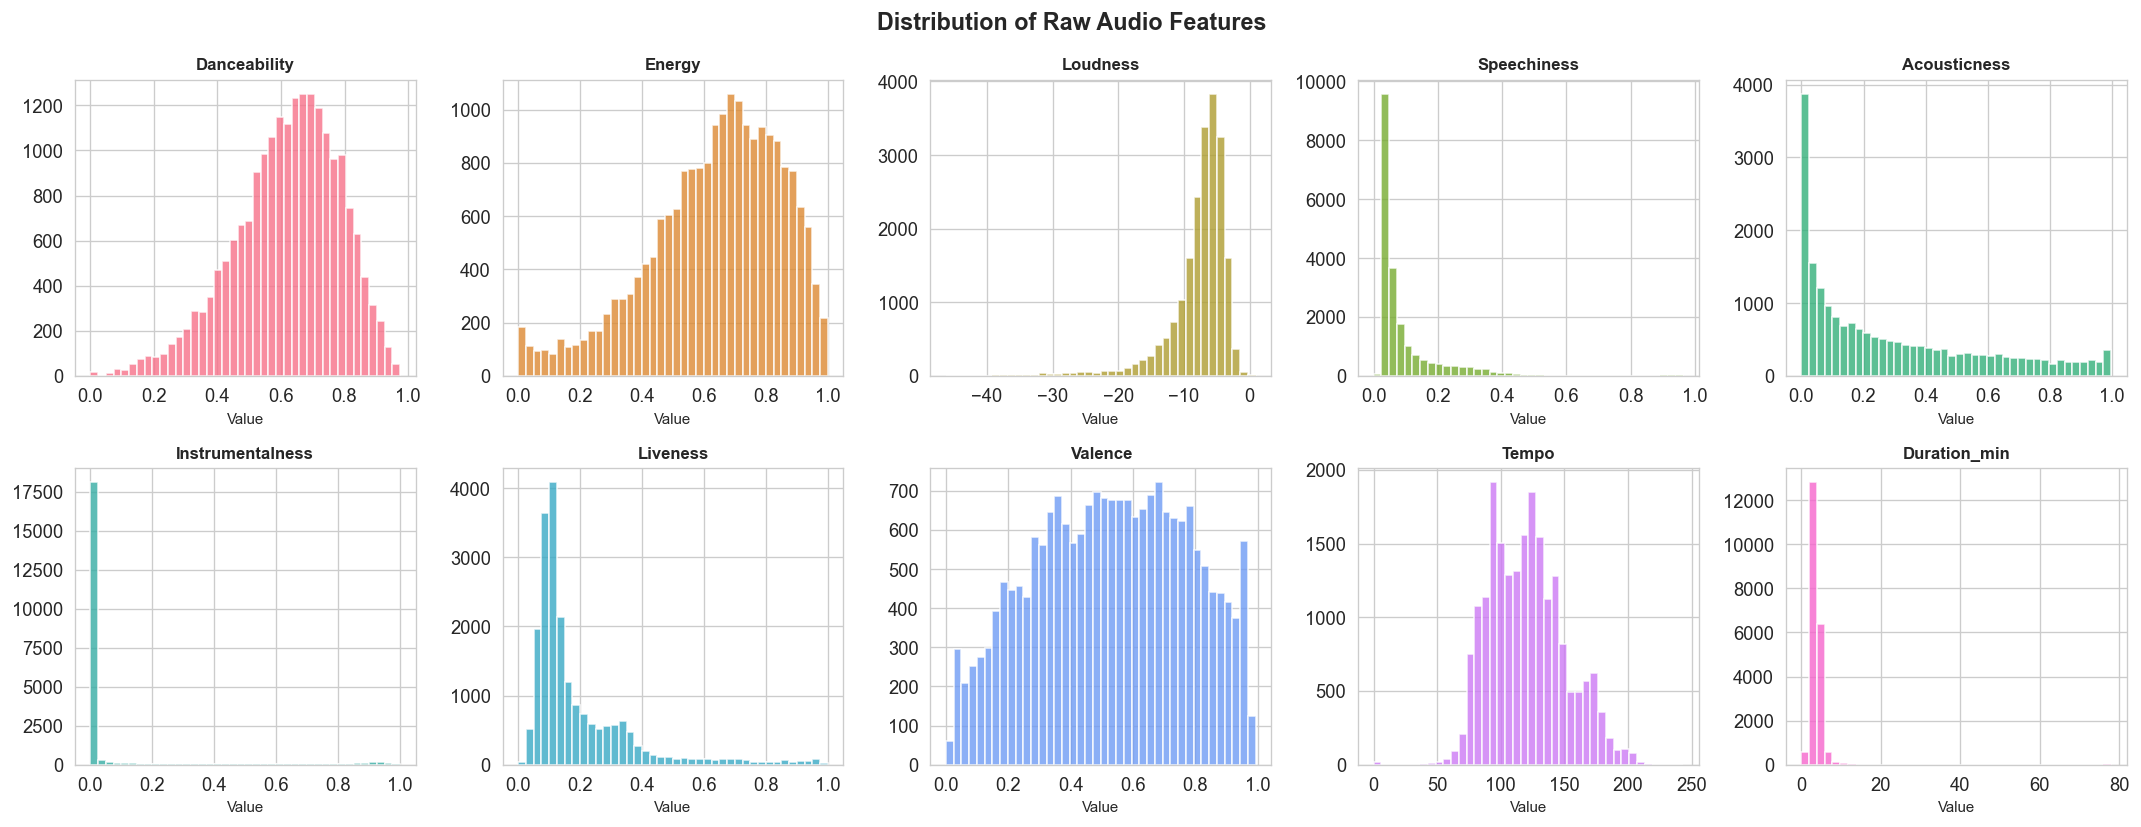

In [9]:
# Visualize distributions
fig, axes = plt.subplots(2, 5, figsize=(18, 7))
axes = axes.flatten()
colors = sns.color_palette('husl', 10)

for i, feat in enumerate(AUDIO_FEATURES):
    axes[i].hist(df[feat], bins=40, color=colors[i], alpha=0.8, edgecolor='white')
    axes[i].set_title(feat, fontweight='bold', fontsize=10)
    axes[i].set_xlabel('Value', fontsize=9)

plt.suptitle('Distribution of Raw Audio Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 5. Log-Transform Engagement Variables

Why? Views, Likes, and Comments are severely right-skewed.  

In [10]:
df_clean = df.copy()

for col in TARGETS:
    df_clean[f'log_{col}'] = np.log1p(df_clean[col])

LOG_TARGETS = ['log_Views', 'log_Likes', 'log_Comments']

# Summary stats comparison
print('Before vs After Log Transformation')
comparison = pd.DataFrame({
    'Variable': TARGETS + LOG_TARGETS,
    'Mean':   [df_clean[c].mean() for c in TARGETS + LOG_TARGETS],
    'Std':    [df_clean[c].std()  for c in TARGETS + LOG_TARGETS],
    'Min':    [df_clean[c].min()  for c in TARGETS + LOG_TARGETS],
    'Max':    [df_clean[c].max()  for c in TARGETS + LOG_TARGETS],
    'Skewness': [df_clean[c].skew() for c in TARGETS + LOG_TARGETS]
}).round(3)
print(comparison.to_string(index=False))

Before vs After Log Transformation
    Variable         Mean          Std  Min          Max  Skewness
       Views 92037403.612 2.726026e+08  0.0 8.079649e+09     9.308
       Likes   647990.154 1.773648e+06  0.0 5.078865e+07     8.747
    Comments    26846.790 1.911751e+05  0.0 1.608314e+07    44.160
   log_Views       15.665 3.675000e+00  0.0 2.281300e+01    -1.947
   log_Likes       11.077 3.115000e+00  0.0 1.774300e+01    -1.430
log_Comments        7.491 2.977000e+00  0.0 1.659300e+01    -0.802


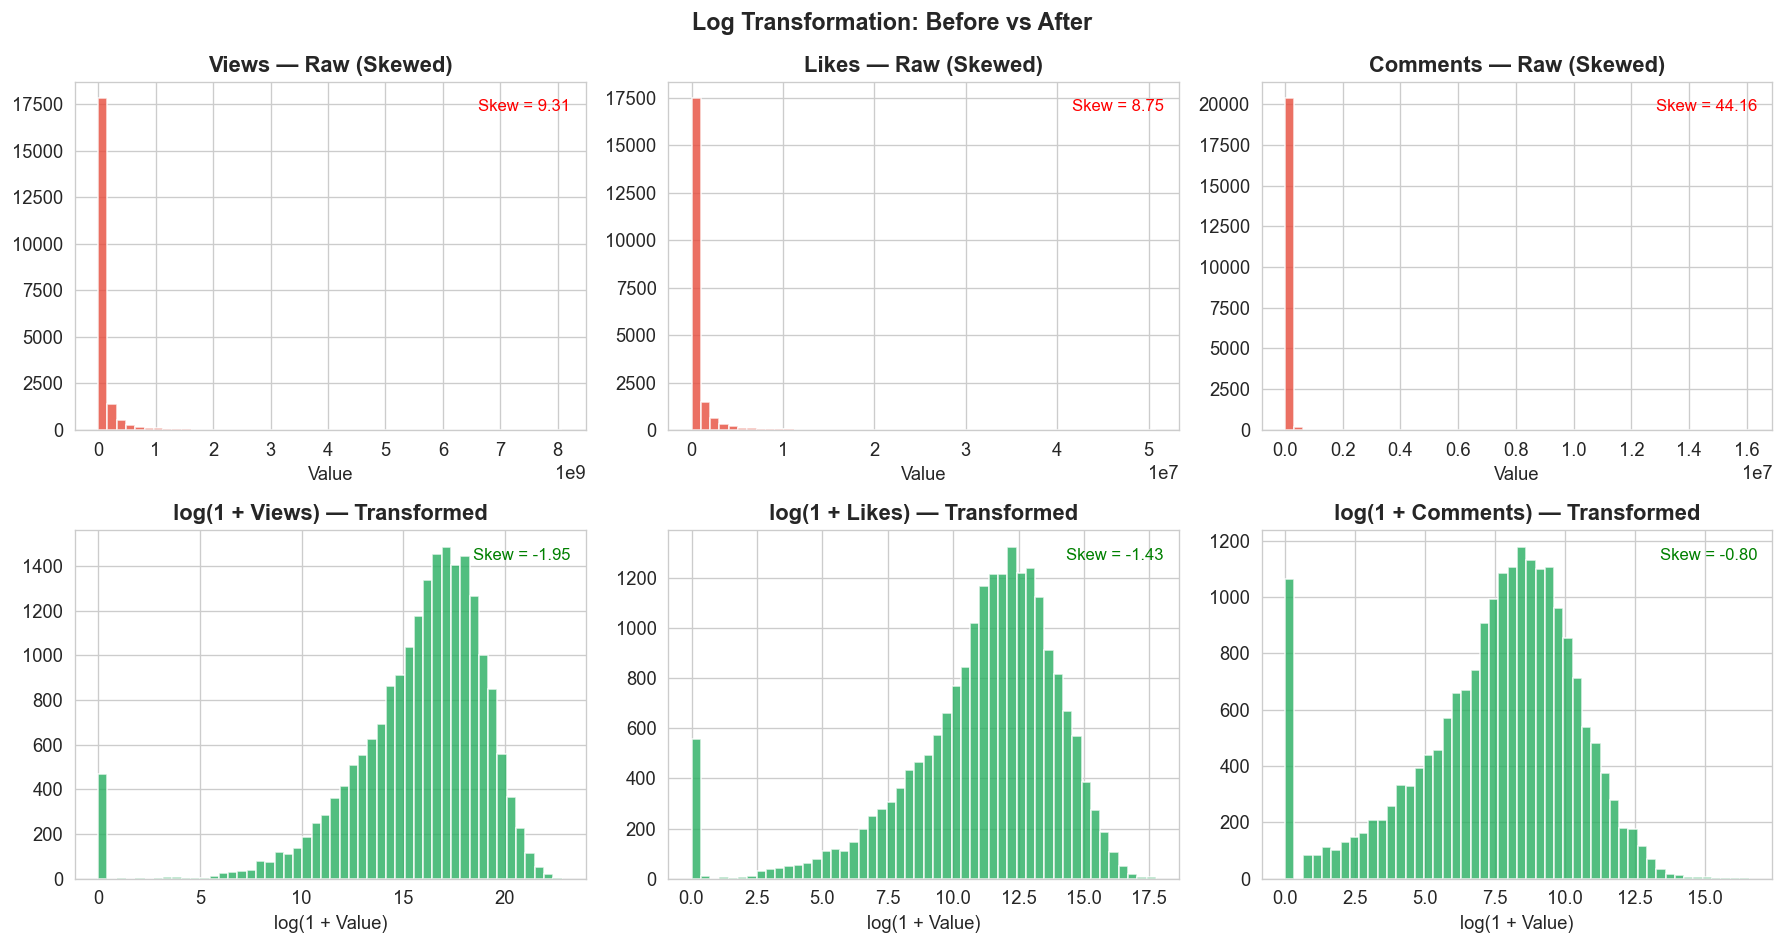

In [11]:
# Before vs after visualization
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

for i, col in enumerate(TARGETS):
    axes[0, i].hist(df_clean[col], bins=50, color='#e74c3c', alpha=0.8, edgecolor='white')
    axes[0, i].set_title(f'{col} — Raw (Skewed)', fontweight='bold')
    axes[0, i].set_xlabel('Value')
    skew_raw = df_clean[col].skew()
    axes[0, i].text(0.97, 0.95, f'Skew = {skew_raw:.2f}', transform=axes[0,i].transAxes,
                    ha='right', va='top', color='red', fontsize=10)

    axes[1, i].hist(df_clean[f'log_{col}'], bins=50, color='#27ae60', alpha=0.8, edgecolor='white')
    axes[1, i].set_title(f'log(1 + {col}) — Transformed', fontweight='bold')
    axes[1, i].set_xlabel('log(1 + Value)')
    skew_log = df_clean[f'log_{col}'].skew()
    axes[1, i].text(0.97, 0.95, f'Skew = {skew_log:.2f}', transform=axes[1,i].transAxes,
                    ha='right', va='top', color='green', fontsize=10)

plt.suptitle('Log Transformation: Before vs After', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [12]:
# Check zero value counts
print("Views = 0:", (df['Views'] == 0).sum())
print("Likes = 0:", (df['Likes'] == 0).sum())
print("Comments = 0:", (df['Comments'] == 0).sum())

# Check first 10 rows of zero value count for Views
print(df[df['Views'] == 0][['Artist','Track','Album_type','Views','Likes','Comments']].head(10))

Views = 0: 470
Likes = 0: 557
Comments = 0: 1065
             Artist                Track Album_type  Views  Likes  Comments
410  Wisin & Yandel          Besos Moja2      album      0      0         0
411  Wisin & Yandel      Mayor Que Usted     single      0      0         0
412  Wisin & Yandel                Vapor      album      0      0         0
413  Wisin & Yandel          Si Te Pillo     single      0      0         0
414  Wisin & Yandel    Noche De Entierro      album      0      0         0
415  Wisin & Yandel  Algo Me Gusta De Ti      album      0      0         0
416  Wisin & Yandel        Noche De Sexo      album      0      0         0
417  Wisin & Yandel      Sexy Movimiento      album      0      0         0
418  Wisin & Yandel          Si Supieras     single      0      0         0
593     Hans Zimmer             S.T.A.Y.      album      0      0         0


In [13]:
# Remove rows where Views equals zero
df_clean = df[df['Views'] > 0].copy()

print(f"Dataset Size After Removal")
print(f"Remaining: {len(df_clean):,} rows")
print(f"Removed  : {len(df) - len(df_clean):,} rows")

# Re-apply log transformation on cleaned data
for col in ['Views', 'Likes', 'Comments']:
    df_clean[f'log_{col}'] = np.log1p(df_clean[col])

Dataset Size After Removal
Remaining: 20,124 rows
Removed  : 470 rows


## 6. Standardize Audio Features

Why？ Audio features have very different scales:  
- Loudness
- Tempo
- Danceability

In [14]:
scaler = StandardScaler()
scaled_cols = [f'{c}_scaled' for c in AUDIO_FEATURES]
df_clean[scaled_cols] = scaler.fit_transform(df_clean[AUDIO_FEATURES])

print('After StandardScaler (mean ≈ 0, std ≈ 1)')
print(df_clean[scaled_cols].describe().round(4).loc[['mean', 'std', 'min', 'max']])

After StandardScaler (mean ≈ 0, std ≈ 1)
      Danceability_scaled  Energy_scaled  Loudness_scaled  Speechiness_scaled  \
mean               0.0000        -0.0000          -0.0000             -0.0000   
std                1.0000         1.0000           1.0000              1.0000   
min               -3.7509        -2.9684          -8.3453             -0.8734   
max                2.1423         1.7067           1.8585              7.8689   

      Acousticness_scaled  Instrumentalness_scaled  Liveness_scaled  \
mean               0.0000                   0.0000          -0.0000   
std                1.0000                   1.0000           1.0000   
min               -1.0108                  -0.2904          -1.1559   
max                2.4731                   4.8753           4.8746   

      Valence_scaled  Tempo_scaled  Duration_min_scaled  
mean         -0.0000        0.0000               0.0000  
std           1.0000        1.0000               1.0000  
min          -2.1549   

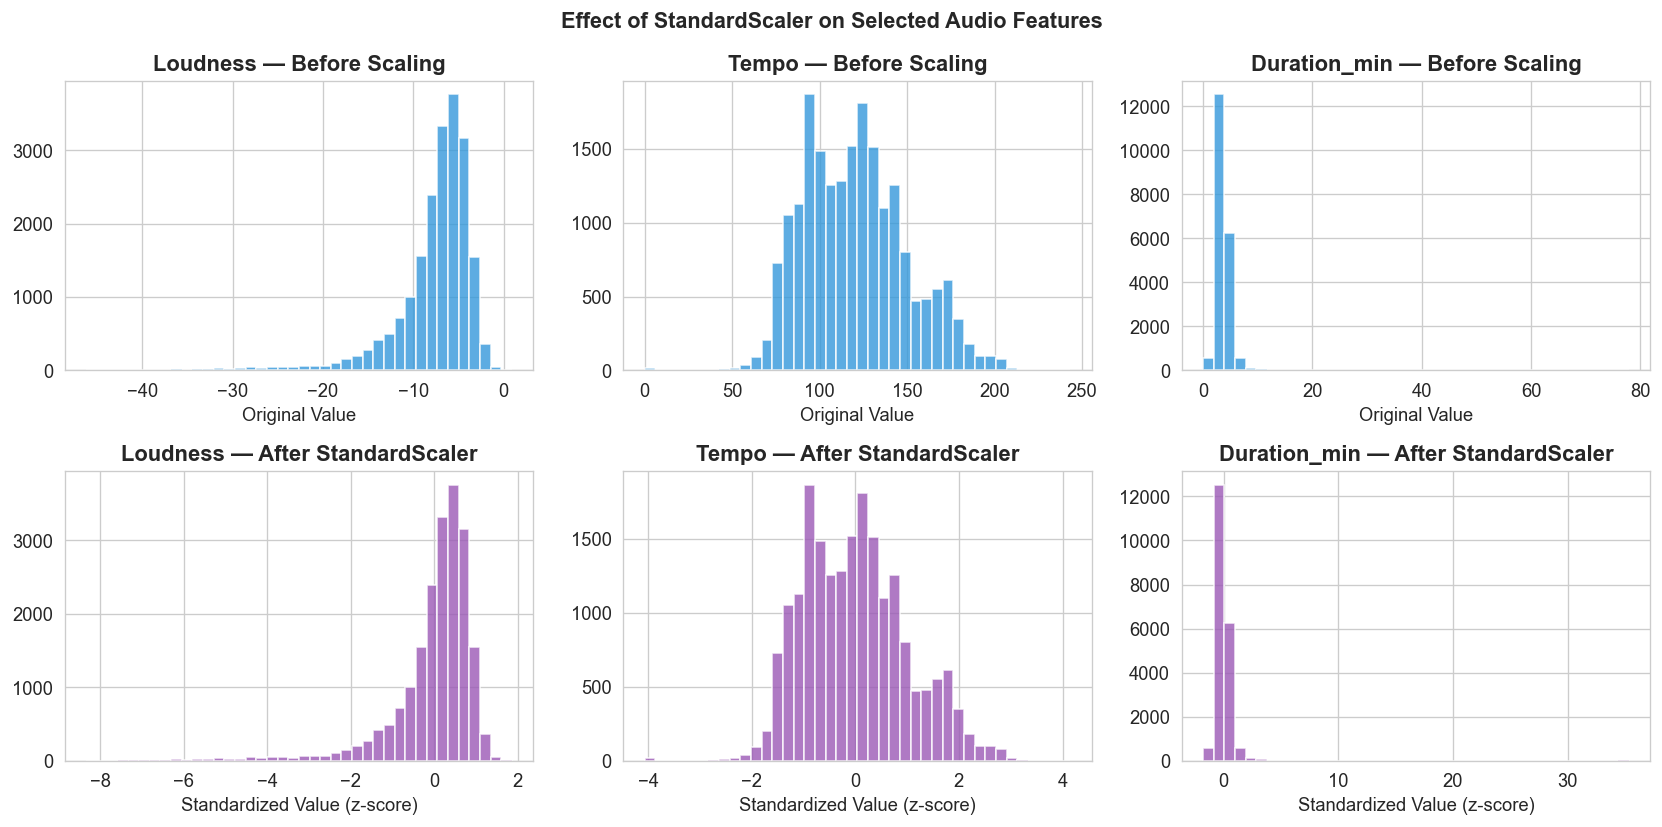

In [15]:
# Visualize scaling effect on 3 features with very different scales
fig, axes = plt.subplots(2, 3, figsize=(14, 7))
demo_feats = ['Loudness', 'Tempo', 'Duration_min']

for i, feat in enumerate(demo_feats):
    axes[0, i].hist(df_clean[feat], bins=40, color='#3498db', alpha=0.8, edgecolor='white')
    axes[0, i].set_title(f'{feat} — Before Scaling', fontweight='bold')
    axes[0, i].set_xlabel('Original Value')

    axes[1, i].hist(df_clean[f'{feat}_scaled'], bins=40, color='#9b59b6', alpha=0.8, edgecolor='white')
    axes[1, i].set_title(f'{feat} — After StandardScaler', fontweight='bold')
    axes[1, i].set_xlabel('Standardized Value (z-score)')

plt.suptitle('Effect of StandardScaler on Selected Audio Features', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 7. Encode Categorical Variable: Album_type

**Why:** Linear regression requires numeric inputs. `Album_type` (album / single / compilation) must be converted.  
**Method:** One-Hot Encoding with `drop_first=True` to avoid multicollinearity (dummy variable trap).

One-Hot Encoding of Album_type
New dummy columns created:
['Album_type_compilation', 'Album_type_single']
Reference category (dropped): album


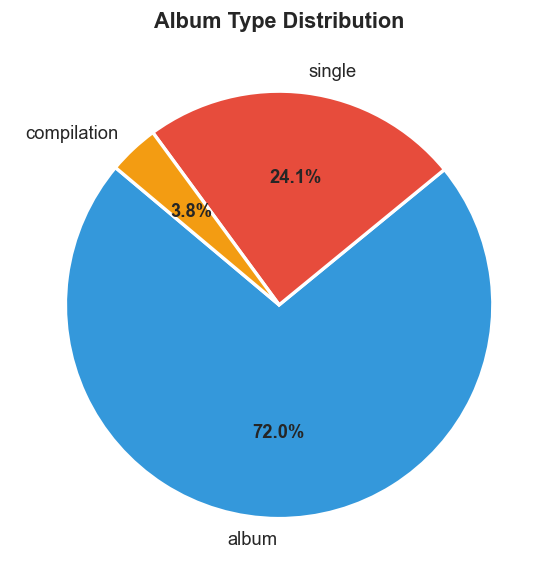

In [16]:
dummies = pd.get_dummies(df_clean['Album_type'], prefix='Album_type', drop_first=True)
df_clean = pd.concat([df_clean, dummies], axis=1)

print('One-Hot Encoding of Album_type')
print('New dummy columns created:')
print(dummies.columns.tolist())
print('Reference category (dropped): album')


# Pie chart
fig, ax = plt.subplots(figsize=(6, 5))
counts = df['Album_type'].value_counts()
wedges, texts, autotexts = ax.pie(
    counts, labels=counts.index, autopct='%1.1f%%',
    colors=['#3498db','#e74c3c','#f39c12'],
    startangle=140, wedgeprops={'edgecolor':'white','linewidth':2}
)
for at in autotexts:
    at.set_fontsize(11); at.set_fontweight('bold')
ax.set_title('Album Type Distribution', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()

## 8. Save Cleaned Dataset

In [17]:
df_clean.to_csv('Spotify_cleaned.csv', index=False)
print('Cleaned dataset saved as: Spotify_cleaned.csv')
print(f'Final shape: {df_clean.shape[0]:,} rows × {df_clean.shape[1]} columns')

Cleaned dataset saved as: Spotify_cleaned.csv
Final shape: 20,124 rows × 39 columns
